In [5]:
from google.colab import files
uploaded = files.upload()

KeyboardInterrupt: 

In [6]:
import pandas as pd
import numpy as np
import json
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

quarterly = pd.read_csv("quarterly_revenue.csv")

quarterly["quarter_start"] = pd.to_datetime(
    quarterly["quarter_start"]
)

quarterly["revenue"] = pd.to_numeric(
    quarterly["revenue"]
)

quarterly = quarterly.sort_values(
    "quarter_start"
).reset_index(drop=True)

print(quarterly)

   quarter_start      revenue
0     2019-01-01   32561730.0
1     2019-04-01   31376467.0
2     2019-07-01   32763819.0
3     2019-10-01   42876672.0
4     2020-01-01   89027379.0
5     2020-04-01   44311539.0
6     2020-07-01   41231030.0
7     2020-10-01   28564037.0
8     2021-01-01    2986590.0
9     2021-04-01   12675818.0
10    2021-07-01   13054906.0
11    2021-10-01  150028047.0
12    2022-01-01   81253357.0
13    2022-04-01   67471015.0
14    2022-07-01   62779615.0
15    2022-10-01   85232418.0
16    2023-01-01   34078655.0
17    2023-04-01   11796066.0
18    2023-07-01   29888909.0
19    2023-10-01   83427507.0


In [7]:
# Basic validation checks

assert quarterly["quarter_start"].notna().all(), \
    "Some quarter dates are missing."

assert quarterly["revenue"].notna().all(), \
    "Some revenue values are missing."

assert (quarterly["revenue"] >= 0).all(), \
    "Revenue should not be negative."

assert quarterly["quarter_start"].is_unique, \
    "Duplicate quarters were found."

print("Validation passed.")
print("Number of quarters:", len(quarterly))
print("Date range:",
      quarterly["quarter_start"].min(),
      "to",
      quarterly["quarter_start"].max())

Validation passed.
Number of quarters: 20
Date range: 2019-01-01 00:00:00 to 2023-10-01 00:00:00


In [8]:
# Create simple modeling variables

quarterly["time_index"] = np.arange(len(quarterly))
quarterly["quarter_number"] = quarterly[
    "quarter_start"
].dt.quarter

# Create Q2, Q3 and Q4 indicator columns.
# Q1 becomes the comparison quarter.

quarter_indicators = pd.get_dummies(
    quarterly["quarter_number"],
    prefix="q",
    drop_first=True,
    dtype=int
)

X = pd.concat(
    [
        quarterly[["time_index"]],
        quarter_indicators
    ],
    axis=1
)

y = quarterly["revenue"]

model = LinearRegression()
model.fit(X, y)

quarterly["fitted_revenue"] = model.predict(X)

mae = mean_absolute_error(
    quarterly["revenue"],
    quarterly["fitted_revenue"]
)

print("Training MAE:", round(mae, 2))
print("Model columns:", list(X.columns))

Training MAE: 23501266.76
Model columns: ['time_index', 'q_2', 'q_3', 'q_4']


In [9]:
future = pd.DataFrame({
    "quarter_start": pd.to_datetime([
        "2024-01-01",
        "2024-04-01",
        "2024-07-01",
        "2024-10-01"
    ])
})

future["time_index"] = np.arange(
    len(quarterly),
    len(quarterly) + len(future)
)

future["quarter_number"] = future[
    "quarter_start"
].dt.quarter

future_indicators = pd.get_dummies(
    future["quarter_number"],
    prefix="q",
    drop_first=True,
    dtype=int
)

future_X = pd.concat(
    [
        future[["time_index"]],
        future_indicators
    ],
    axis=1
)

future_X = future_X.reindex(
    columns=X.columns,
    fill_value=0
)

future["forecast_revenue"] = model.predict(future_X)

future["forecast_revenue"] = future[
    "forecast_revenue"
].clip(lower=0)

print(future[[
    "quarter_start",
    "forecast_revenue"
]])

forecast_total = future["forecast_revenue"].sum()

print(
    "Illustrative 2024 forecast:",
    round(forecast_total, 2)
)

  quarter_start  forecast_revenue
0    2024-01-01       57943591.05
1    2024-04-01       43488229.85
2    2024-07-01       45905704.65
3    2024-10-01       87987785.05
Illustrative 2024 forecast: 235325310.6


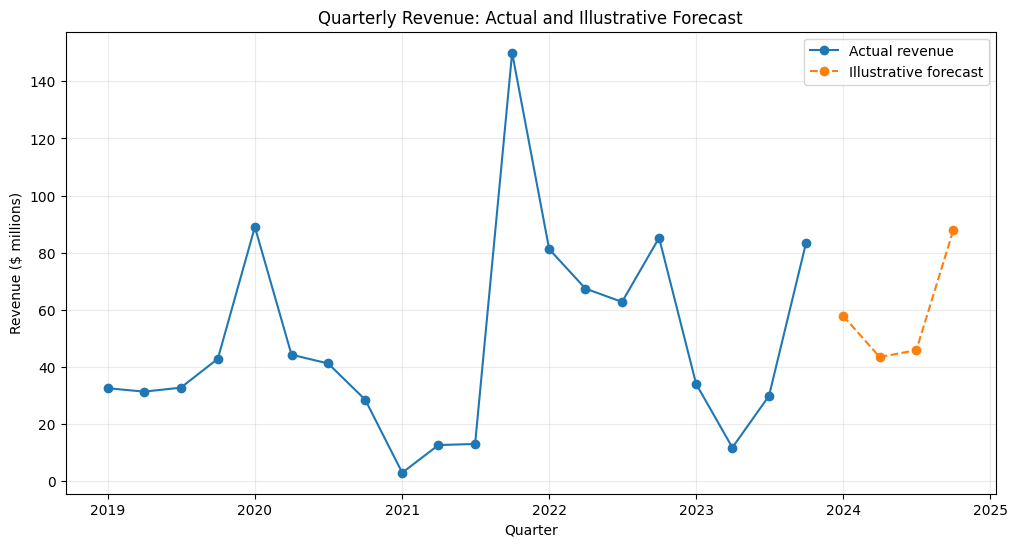

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    quarterly["quarter_start"],
    quarterly["revenue"] / 1_000_000,
    marker="o",
    label="Actual revenue"
)

plt.plot(
    future["quarter_start"],
    future["forecast_revenue"] / 1_000_000,
    marker="o",
    linestyle="--",
    label="Illustrative forecast"
)

plt.title("Quarterly Revenue: Actual and Illustrative Forecast")
plt.xlabel("Quarter")
plt.ylabel("Revenue ($ millions)")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [11]:
quarterly_output = quarterly[[
    "quarter_start",
    "revenue",
    "fitted_revenue"
]].copy()

forecast_output = future[[
    "quarter_start",
    "forecast_revenue"
]].copy()

quarterly_output.to_csv(
    "quarterly_revenue_validated.csv",
    index=False
)

forecast_output.to_csv(
    "forecast_2024.csv",
    index=False
)

dashboard_metrics = {
    "method": "Linear regression with time trend and quarterly indicators",
    "training_period": "2019-01-01 through 2023-12-31",
    "training_mae": round(float(mae), 2),
    "forecast_2024": [
        {
            "quarter": row["quarter_start"].strftime("%Y-Q")
                       + str(row["quarter_start"].quarter),
            "revenue": round(float(row["forecast_revenue"]), 2)
        }
        for _, row in future.iterrows()
    ],
    "forecast_2024_total": round(float(forecast_total), 2),
    "warning": (
        "Illustrative portfolio model. Dataset anomalies and "
        "incomplete periods limit decision use."
    )
}

with open("dashboard_metrics.json", "w") as file:
    json.dump(dashboard_metrics, file, indent=2)

print("Files created successfully.")

Files created successfully.


In [12]:
from google.colab import files

files.download("quarterly_revenue_validated.csv")
files.download("forecast_2024.csv")
files.download("dashboard_metrics.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>